<a href="https://colab.research.google.com/github/saivarun405/ITA0516_Computer-vision_B/blob/main/CV_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
!pip install opencv-python numpy pandas matplotlib

In [16]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import time

In [17]:
from google.colab import files

uploaded = files.upload()

Saving defected and non.jpg to defected and non.jpg


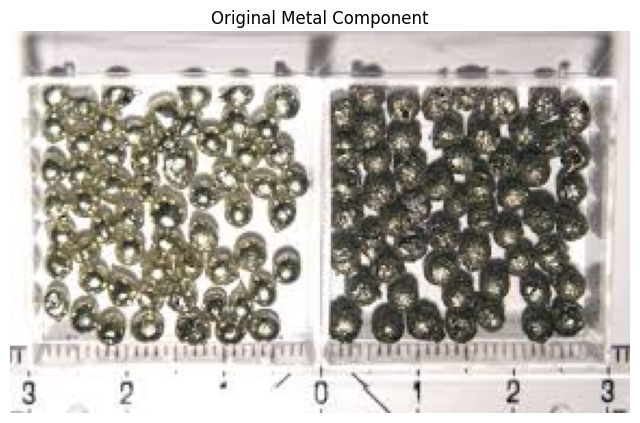

In [18]:
filename = list(uploaded.keys())[0]

image = cv2.imread(filename)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8, 6))
plt.imshow(image_rgb)
plt.title("Original Metal Component")
plt.axis("off")
plt.show()

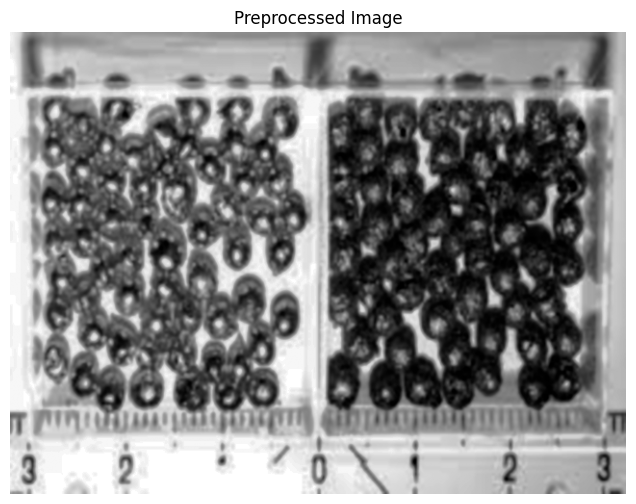

In [19]:
resized = cv2.resize(image, (640, 480))

gray = cv2.cvtColor(resized, cv2.COLOR_BGR2GRAY)

blurred = cv2.GaussianBlur(gray, (5, 5), 0)

enhanced = cv2.equalizeHist(blurred)

plt.figure(figsize=(8, 6))
plt.imshow(enhanced, cmap="gray")
plt.title("Preprocessed Image")
plt.axis("off")
plt.show()

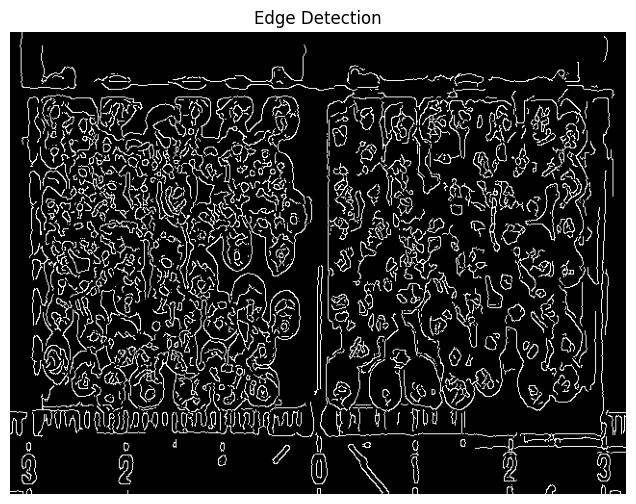

In [20]:
edges = cv2.Canny(
    enhanced,
    50,
    150
)

plt.figure(figsize=(8, 6))
plt.imshow(edges, cmap="gray")
plt.title("Edge Detection")
plt.axis("off")
plt.show()

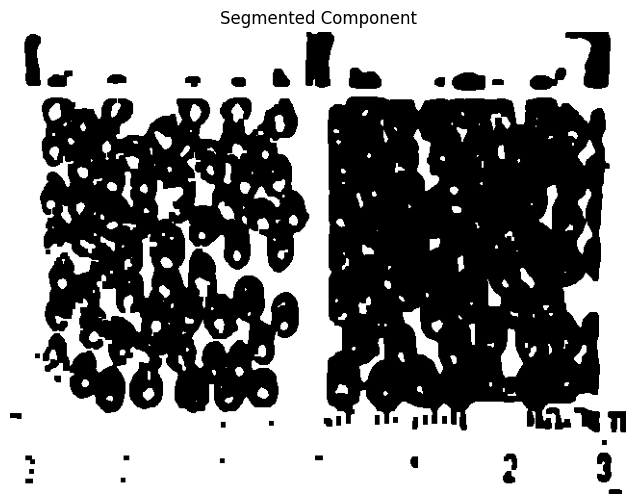

In [21]:
_, binary = cv2.threshold(
    enhanced,
    0,
    255,
    cv2.THRESH_BINARY + cv2.THRESH_OTSU
)

kernel = np.ones((5, 5), np.uint8)

binary = cv2.morphologyEx(
    binary,
    cv2.MORPH_CLOSE,
    kernel
)

plt.figure(figsize=(8, 6))
plt.imshow(binary, cmap="gray")
plt.title("Segmented Component")
plt.axis("off")
plt.show()

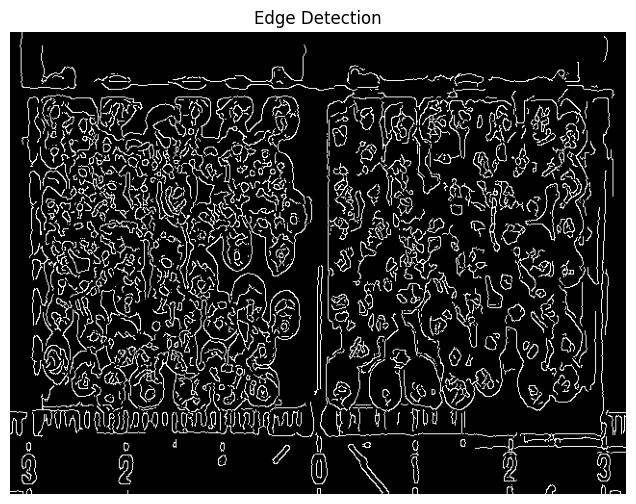

In [22]:
edges = cv2.Canny(
    enhanced,
    50,
    150
)

plt.figure(figsize=(8, 6))
plt.imshow(edges, cmap="gray")
plt.title("Edge Detection")
plt.axis("off")
plt.show()

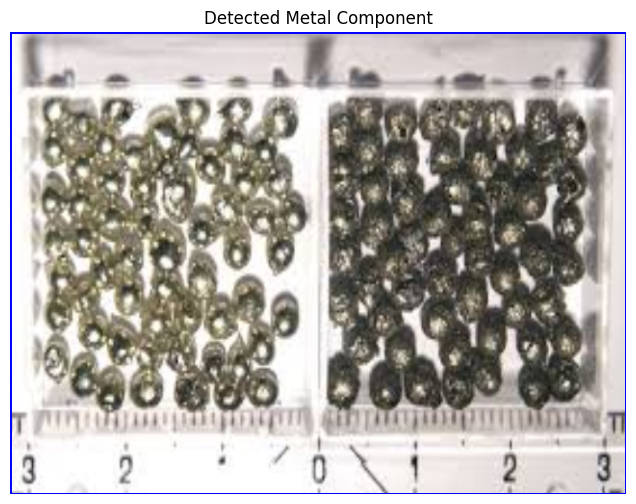

In [23]:
contours, _ = cv2.findContours(
    binary,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

output = resized.copy()

if contours:
    component = max(contours, key=cv2.contourArea)

    x, y, w, h = cv2.boundingRect(component)

    cv2.rectangle(
        output,
        (x, y),
        (x + w, y + h),
        (255, 0, 0),
        2
    )

plt.figure(figsize=(8, 6))
plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
plt.title("Detected Metal Component")
plt.axis("off")
plt.show()

In [24]:
roi = resized[y:y+h, x:x+w]

roi_gray = cv2.cvtColor(
    roi,
    cv2.COLOR_BGR2GRAY
)

roi_blur = cv2.GaussianBlur(
    roi_gray,
    (5, 5),
    0
)

defect_edges = cv2.Canny(
    roi_blur,
    50,
    150
)

defect_contours, _ = cv2.findContours(
    defect_edges,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

defects = []

for contour in defect_contours:

    area = cv2.contourArea(contour)

    if 20 < area < 5000:
        defects.append(contour)

print("Number of detected defect regions:", len(defects))

Number of detected defect regions: 163


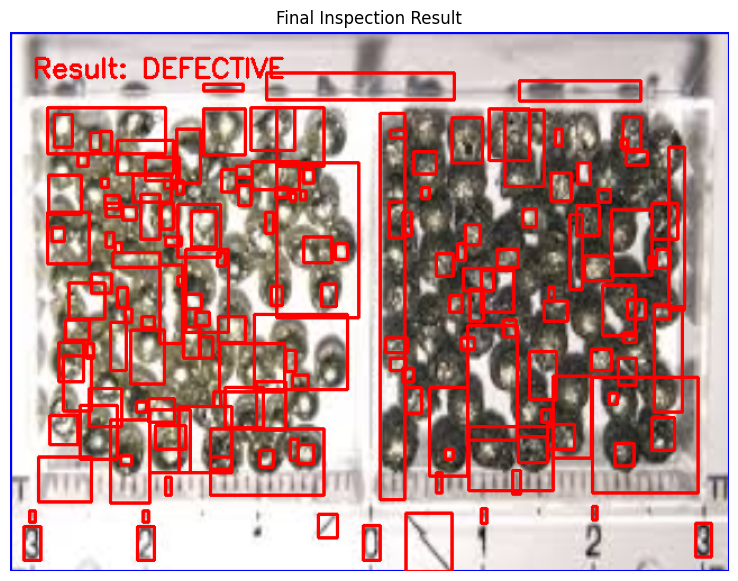

Final Classification: DEFECTIVE


In [25]:
result = resized.copy()

cv2.rectangle(
    result,
    (x, y),
    (x+w, y+h),
    (255, 0, 0),
    2
)

for contour in defects:

    dx, dy, dw, dh = cv2.boundingRect(contour)

    cv2.rectangle(
        result,
        (x+dx, y+dy),
        (x+dx+dw, y+dy+dh),
        (0, 0, 255),
        2
    )

if len(defects) > 0:
    status = "DEFECTIVE"
else:
    status = "NON-DEFECTIVE"

cv2.putText(
    result,
    "Result: " + status,
    (20, 40),
    cv2.FONT_HERSHEY_SIMPLEX,
    0.8,
    (0, 0, 255),
    2
)

plt.figure(figsize=(10, 7))
plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
plt.title("Final Inspection Result")
plt.axis("off")
plt.show()

print("Final Classification:", status)